**Using PINNs to find out how long it takes for a beer (or non-alcoholic, for those who prefer so :)) bottle to cool down in a fridge**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PINN_3d import *
from FFEM_building_blocks import Mesh
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt

In [ ]:
# Modelling the bottle as an infinitely long (not true, but whatever, I want to stick to 2 spatial dimensions) cylinder of radius R
# the bottle is originally at 22 degrees
# It sits in the fridge with no convective heat trasnfer, just constant temperature at the boundary (4 C)
# Goal: understand when the average temperature of the bottle cools down to a target temperature (say 6 C)
# simple heat equation with Dirichlet boundary conditions, no recirculations inside the bottle

bottle_radius = 0.02
alpha_water = 0.133e-6 #m2/s thermal diffusivity of water

#strategy: solve for alpha = 1. then rescale t -> t / alpha_water in the solution
bottle_pinn = PINN_heat_2d_circle(N_internal_nodes=16, f_initial=lambda x: 22, f_dirichlet=lambda x: 4, R=bottle_radius, t_bounds=(0,0.025), alpha = 1)
bottle_pinn.set_collocation_points(3000)
bottle_pinn.compute_initial_values(1000, 0)
bottle_pinn.compute_boundary_values(2000)
bottle_pinn.compute_physics_loss()

bottle_pinn.train_RAD(weight_bdy=100)

Epoch [1000/30000], N_collocation_points: 3300, Loss: 2945.4556
Epoch [2000/30000], N_collocation_points: 3700, Loss: 2945.4546
Epoch [3000/30000], N_collocation_points: 4100, Loss: 2945.4534
Epoch [4000/30000], N_collocation_points: 4500, Loss: 2945.1858
Epoch [5000/30000], N_collocation_points: 4900, Loss: 2945.4546
Epoch [6000/30000], N_collocation_points: 5300, Loss: 2945.4543
Epoch [7000/30000], N_collocation_points: 5700, Loss: 2945.4541
Epoch [8000/30000], N_collocation_points: 6100, Loss: 2945.4531
Epoch [9000/30000], N_collocation_points: 6500, Loss: 2945.3423
Epoch [10000/30000], N_collocation_points: 6900, Loss: 2945.4753
Epoch [11000/30000], N_collocation_points: 7300, Loss: 2945.4619
Epoch [12000/30000], N_collocation_points: 7700, Loss: 2945.4648
Epoch [13000/30000], N_collocation_points: 8100, Loss: 2945.4536
Epoch [14000/30000], N_collocation_points: 8500, Loss: 2945.4543
Epoch [15000/30000], N_collocation_points: 8900, Loss: 2945.4541
Epoch [16000/30000], N_collocation

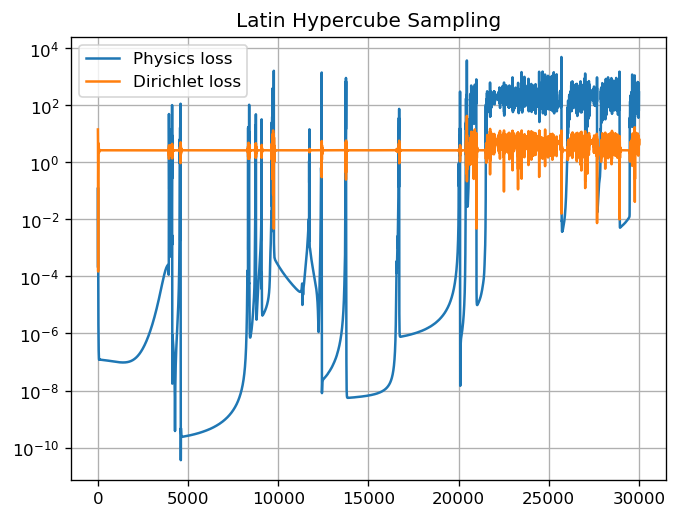

In [12]:

plt.figure(dpi= 120)
plt.title('Latin Hypercube Sampling')
plt.semilogy(bottle_pinn.physics_losses, label = "Physics loss")
plt.semilogy(bottle_pinn.dirichlet_losses, label = "Dirichlet loss")
plt.grid(True)
plt.legend()
plt.show()

/var/folders/59/t4572hz13tg2y_6ql18g7cvw0000gn/T/ipykernel_21736/1763721147.py:22: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(X, Y, res, cmap='viridis', shading='auto')


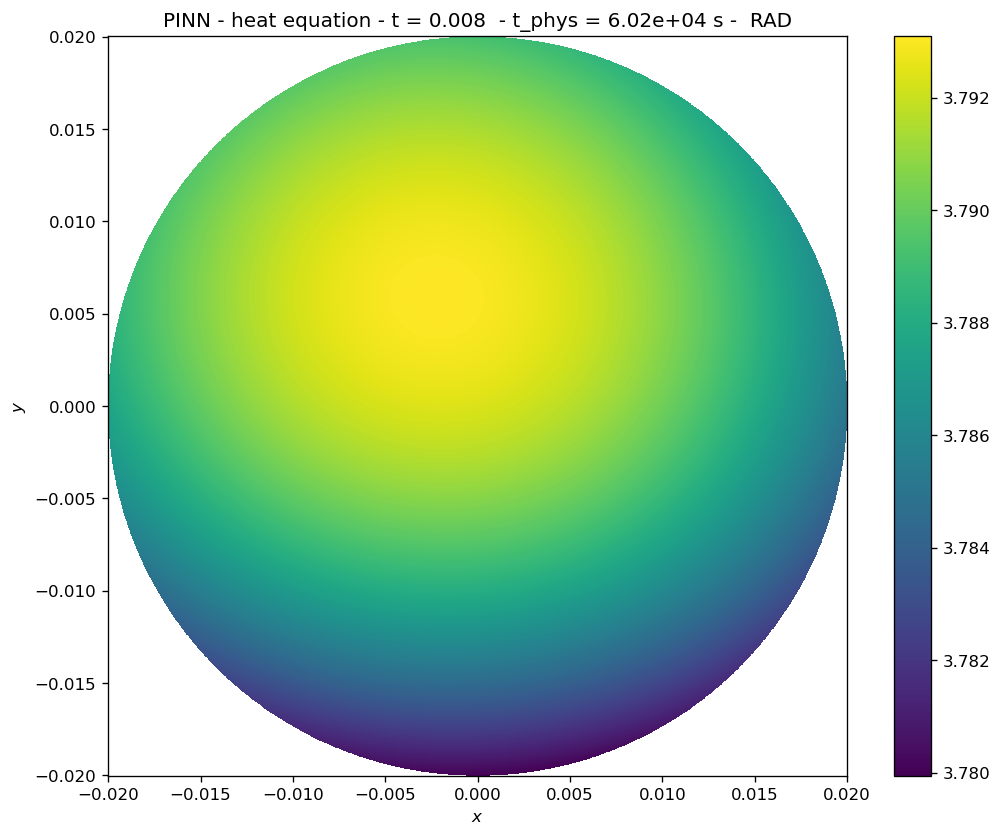

In [13]:
radius = 0.02
t_check = 0.008

N_r, N_theta = 1000, 2000
r = np.linspace(0, radius, N_r)
theta = np.linspace(0, 2*np.pi, N_theta)
R, Theta = np.meshgrid(r, theta)  # both shape (N_theta, N_r)

X = R * np.cos(Theta)
Y = R * np.sin(Theta)

grid_points = np.stack([X.ravel(), Y.ravel(), t_check * np.ones_like(X.ravel())], axis=1)
grid_points_torch = torch.tensor(grid_points, dtype=torch.float32)

with torch.no_grad():
    u_pred = bottle_pinn.model(grid_points_torch)  # shape (N_theta*N_r, 1)

res = u_pred.numpy().reshape(X.shape)  # back to (N_theta, N_r) to match X, Y grid

fig, ax = plt.subplots(figsize=(10, 8), dpi = 120)
#pcm = ax.pcolormesh(X, Y, res, cmap='viridis', shading='auto', vmin=4, vmax=20)
pcm = ax.pcolormesh(X, Y, res, cmap='viridis', shading='auto')
ax.set_aspect('equal')
fig.colorbar(pcm, ax=ax)
ax.set_title(f'PINN - heat equation - t = {t_check}  - t_phys = {t_check/alpha_water:.3g} s -  RAD')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.savefig('results/heat_pinn.png')
plt.show()

# STUFF TO DO/PROBLEMS TO FIX

convergence slow. when I train on small times (which is the range I am interested in) even worse, converges often to the trivial solution

also, difficult to see a nice gradient on the boundary. tried raising the boundary weight to 100 (from 10), did not really work. 

plus the cooling down seems a bit slow, compared to experience. should need to check with my next beer :)


gradient-norm balancing: see https://arxiv.org/pdf/2001.04536


## Reparametrisation/hard constraint

*the solution converges too often to the trivial solution, and gets stuck*

So I define the solution as 

$T(x,y,z) = A(t) + D(x,y)t N(x,y,t)$

where $N(x,y,t)$ is the function to "solve" for.

I use:
$A(t) = T_{in} \, e^{-t/\tau} + T_{bdy} \,(1 - e^{-t/\tau})$

$D(x,y) = R^2 - x^2 - y^2$

The initial and boundary conditions are then automatically satisfied, provided $\tau$ is small enough.

After computing all derivaties the heat equation becomes: 

$\frac{(T_{bdy} -T_{in} )}{\tau}\,e^{-t/\tau} + (R^2 - x^2 - y^2)N + t \,(R^2 - x^2 - y^2)\, \partial_t N + \alpha \, t \, \big( 4N + 4x \, \partial_x N + 4y \, \partial_y N - (R^2 -x^2 - y^2)\, \Delta N\big) = 0$ 

(this last equation is purely pedagogical, in the code I define $T = A + D\,t\,N$ and let autograd do the differentiations)

We work with N in our PINN.

see for instance:
Lagaris, I. E., Likas, A., & Fotiadis, D. I. (1998). "Artificial Neural Networks for Solving Ordinary and Partial Differential Equations." IEEE Transactions on Neural Networks, 9(5), 987–1000

Sukumar, N., & Srivastava, A. (2022). "Exact imposition of boundary conditions with distance functions in physics-informed deep neural networks." Computer Methods in Applied Mechanics and Engineering, 389, 114333.

In [3]:
bottle_radius = 0.02
alpha_water = 0.133e-6 #m2/s thermal diffusivity of water
final_time = 2*3600. # two hours
R_bottle = 0.02 # in meters
alpha_eq = alpha_water*final_time/R_bottle**2 # reparametrization
print(alpha_eq)

2.394


In [ ]:
#strategy: solve for alpha = 1. then rescale t -> t / alpha_water in the solution
bottle_pinn = PINN_heat_2d_circle_reparametrised(N_internal_nodes=16, f_initial=lambda x: 22, f_dirichlet=lambda x: 4, t_bounds=(0,0.025), tau = 0.025/10, alpha = alpha_eq)
bottle_pinn.set_collocation_points(3000)
bottle_pinn.compute_physics_loss()

bottle_pinn.train_RAD()

Epoch [1000/30000], N_collocation_points: 3300, Loss: 2479897.5000
Epoch [2000/30000], N_collocation_points: 3700, Loss: 2390279.2500


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1061897f0>>
Traceback (most recent call last):
  File "/opt/homebrew/anaconda3/lib/python3.13/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


**Loss diverges and this causes problems with the RAD algorithm** (even after reparametrization and redimensionalisation)

TO DO: fix this